#### Data Wrangling :

>> also called data cleaning.

Data wrangling is the process of `cleaning`, `transforming` and `organizing`, so it can be used for `analysis` and `visualization`. it is the important step in the data analysis process b/c raw data is some time incomplete, inconsistent and is is unstructured format, which can make difficult to work with. 
Data wrangling helps to make the data more `consistent`, `accurate` and `usefull for analysis and decision making`.

##### STEPs :
1. gathering the data
2. tools to clean the data (Libraries)
3. how to do 


In [2]:
# Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
df = sns.load_dataset('titanic')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [4]:
df.describe()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [5]:
df.drop(columns=['deck'], inplace=True)

##### Dealing With Missing Values :

In [6]:
df.isnull().sum()/len(df)* 100

survived        0.000000
pclass          0.000000
sex             0.000000
age            19.865320
sibsp           0.000000
parch           0.000000
fare            0.000000
embarked        0.224467
class           0.000000
who             0.000000
adult_male      0.000000
embark_town     0.224467
alive           0.000000
alone           0.000000
dtype: float64

In [7]:
df['age'] = df.age.fillna(value = df['age'].mean()) # OR
df['age'].fillna(df['age'].mean(), inplace=True)

In [8]:
df['embarked'] = df.embarked.fillna(value = df['embarked'].mode()[0])

In [9]:
df['embark_town'] = df.embark_town.fillna(value = df['embark_town'].mode()[0])

In [10]:
df.isnull().sum()/len(df)* 100

survived       0.0
pclass         0.0
sex            0.0
age            0.0
sibsp          0.0
parch          0.0
fare           0.0
embarked       0.0
class          0.0
who            0.0
adult_male     0.0
embark_town    0.0
alive          0.0
alone          0.0
dtype: float64

##### Outliers removal :

###### we have multiple Methods 

### 1. Visualization Method :

<Axes: xlabel='sex', ylabel='age'>

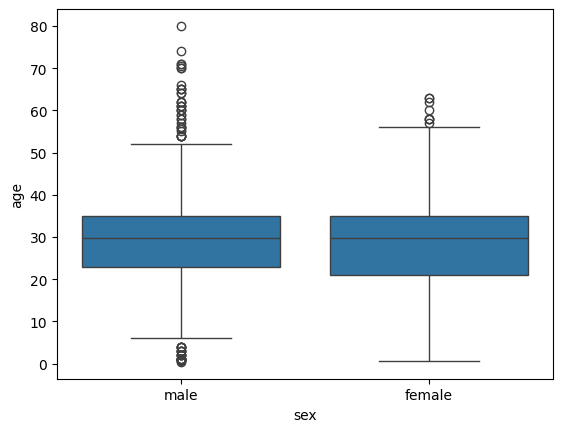

In [11]:
import seaborn as sns
sns.boxplot(data= df, y='age', x='sex')

##### 2. IQR(Inter Quartile Range) methods :

In [12]:
Q1 = df['age'].quantile(0.25)
Q3 = df['age'].quantile(0.75)
IQR = Q3 - Q1
IQR
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df = df[(df['age'] > lower_bound) & (df['age'] < upper_bound)]

In [13]:
df.shape

(825, 14)

#### Day :35 
##### Finding and dropping Duplicate 

1. Finding 

In [14]:
df.duplicated().sum()

np.int64(109)

In [15]:
df_duplicates = df[df.duplicated()]
df_duplicates.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
47,1,3,female,29.699118,0,0,7.7500,Q,Third,woman,False,Queenstown,yes,True
76,0,3,male,29.699118,0,0,7.8958,S,Third,man,True,Southampton,no,True
77,0,3,male,29.699118,0,0,8.0500,S,Third,man,True,Southampton,no,True
87,0,3,male,29.699118,0,0,8.0500,S,Third,man,True,Southampton,no,True
95,0,3,male,29.699118,0,0,8.0500,S,Third,man,True,Southampton,no,True


2. Dropping :

In [16]:
df.drop_duplicates(inplace=True)    

In [17]:
df.shape 

(716, 14)

##### Data Normalization : 

In [19]:
# step : 1. Libraries
import pandas as pd
from sklearn.preprocessing import MinMaxScaler


In [ ]:
# step : 2. DAta
df


In [21]:
# step : 3.select columns to normalize
cols_to_normalize =['age','fare']

In [22]:
# step : 4.create the scaler function
scaler = MinMaxScaler()
# when you want to scale the data instead of 0-1 i.e of your desired, we c  an use feature_range parameter in the MinMaxScaler function.
#scaler = MinMaxScaler(feature_range=(0,10)) 

In [23]:
# step : 5.fit and transform the data and vice versa
df[cols_to_normalize] = scaler.fit_transform(df[cols_to_normalize])

In [ ]:
#step : 6. Check the data 
df

In [25]:
df.describe() # data is now in a scale of 0-1 
# min 0 and max 1, Scaling/transforming done 

,survived,pclass,age,sibsp,parch,fare
count,716.000000,716.000000,716.000000,716.000000,716.000000,716.000000
mean,0.412011,2.277933,0.507194,0.509777,0.393855,0.066769
std,0.492541,0.845962,0.211678,0.961447,0.833673,0.102962
min,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,0.372549,0.000000,0.000000,0.015469
50%,0.000000,3.000000,0.523512,0.000000,0.000000,0.030254
75%,1.000000,3.000000,0.627451,1.000000,0.000000,0.061807
max,1.000000,3.000000,1.000000,8.000000,6.000000,1.000000


##### We can do the same thing for scaling using StandardScaler

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# step : 2. DAta
df

# step : 3.select columns to normalize
cols_to_normalize =['age','fare']

# step : 4.create the scaler function
scaler = StandardScaler()

# step : 5.fit and transform the data and vice versa
df[cols_to_normalize] = scaler.fit_transform(df[cols_to_normalize])

# step : 6. Check the data 
df

In [29]:
df.describe() # data is now in a scale of 0-1

,survived,pclass,age,sibsp,parch,fare
count,716.000000,716.000000,7.160000e+02,716.000000,716.000000,7.160000e+02
mean,0.412011,2.277933,3.572561e-16,0.509777,0.393855,7.318789e-17
std,0.492541,0.845962,1.000699e+00,0.961447,0.833673,1.000699e+00
min,0.000000,1.000000,-2.397743e+00,0.000000,0.000000,-6.489325e-01
25%,0.000000,1.000000,-6.365308e-01,0.000000,0.000000,-4.985913e-01
50%,0.000000,3.000000,7.714171e-02,0.000000,0.000000,-3.548898e-01
75%,1.000000,3.000000,5.685090e-01,1.000000,0.000000,-4.821997e-02
max,1.000000,3.000000,2.329721e+00,8.000000,6.000000,9.070205e+00


x_stand = (x - mean(x))/ std(x)

x_stand is the standarized variable/
x is the original value
mean(x) is the mean of variable x
std(x) is the standard deviation of variable x.